In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy import stats
from iminuit import Minuit, cost

from matplotlib.markers import MarkerStyle

my_cmap = plt.colormaps["rainbow"]
my_marker=MarkerStyle(marker="1", fillstyle='full', transform=None, capstyle=None, joinstyle=None)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['savefig.dpi']=600
plt.rcParams["savefig.bbox"]='tight'
plt.rcParams["figure.figsize"]='5,3'
text_style = dict(horizontalalignment='right', verticalalignment='center',
                  fontsize=12, fontfamily='monospace')

r = np.random
r.seed(42)

In [4]:
def fct(x,a,b):

    y=1 + a*x + b*x**2
    return y


def fit_func_normalized(x,a,b) :
    #integral=scipy.integrate.quad(lambda x: fct(x,a,b), x_min, x_max)[0]
    integral= (2 * (1 + b / 3))
    y=fct(x,a,b)/integral
    return y


def neg_ln_likelihood(array,a,b):
    llh=0
    for x in array:
        y=fit_func_normalized(x,a, b)
        if y<=0:
            raise ValueError(f"Function value is non-positive for x={x}, a={a}, b={b}. Cannot compute log-likelihood.")
        llh=-np.log(y)+llh
    return llh




def sample_data_via_accept_reject(xmin:float=0, xmax:float=1, N_samples:int=10000, a:float=0.0, b:float=0.0)->np.array:
    """data generated with accept/reject method for given function within given boundaries, returns array of accepted x values
    Args:        xmin (float, optional): minimum x value. Defaults to 0.
        xmax (float, optional): maximum x value. Defaults to 1.
        N_samples (int, optional): number of accepted samples to generate. Defaults to 10000.
        a (float, optional): parameter a of the function. Defaults to 0.
        b (float, optional): parameter b of the function. Defaults to 0.
    Returns:
        np.array: array of accepted x values
    """
    x_accepted = np.zeros(N_samples)

    list_x = np.linspace(xmin, xmax, 1000)
    list_y = fit_func_normalized(list_x,a,b)
    ymax = np.max(list_y)*1.1
    #print(f'Maximum of function: {ymax}')

    for i in range(N_samples):
        while True:
            x_rand = r.uniform(xmin, xmax)  
            y_rand = r.uniform(0, ymax)            
            if (y_rand < fit_func_normalized(x_rand,a,b)):
                break
                
        x_accepted[i] = x_rand
    return x_accepted

-0.949764 0.948882


Text(0.5, 1.0, 'Histogram of read data')

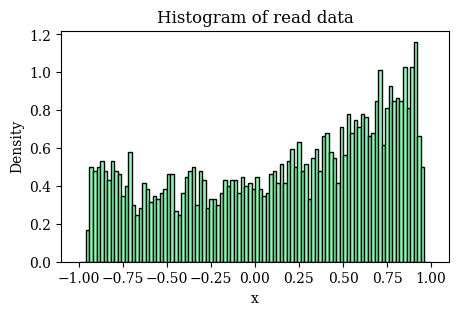

In [7]:
df = pd.read_csv('ParameterEstimation_Ex1.txt',header=None, names=['x'])

print(df["x"].min(), df["x"].max())
x_min = -1
x_max = 1

fig,ax=plt.subplots(1)
ax.hist(df["x"], bins=100, range=(x_min, x_max), density=True,color=my_cmap(0.5), edgecolor='black',rwidth=1,label="read data")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_title("Histogram of read data")


## #2a


In [9]:
#generate raster data of likelihood and llh
n_a=20
n_b=20
a_min=0
a_max=1
b_min=0
b_max=1


raster_array_llh=np.zeros([n_a,n_b])

a_values=np.linspace(a_min, a_max, n_a)
b_values=np.linspace(b_min, b_max, n_b)

for i_a,a in enumerate(a_values):
    for i_b,b in enumerate(b_values):
        llh=neg_ln_likelihood(df["x"],a,b)
        raster_array_llh[i_a,i_b]=llh

In [13]:
a_values.shape
raster_array_llh.shape
meshgrid_a, meshgrid_b = np.meshgrid(a_values, b_values, indexing='ij')
meshgrid_llh = raster_array_llh

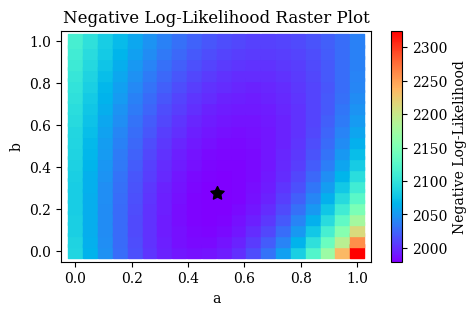

In [32]:
fig_raster,ax_raster=plt.subplots(1)

ax_raster.scatter(meshgrid_a,meshgrid_b, c=meshgrid_llh, marker = 's', s = 100 ,cmap=my_cmap)
ax_raster.set_xlabel("a")
ax_raster.set_ylabel("b")
ax_raster.scatter(0.504, 0.275, color='black', marker=(5, 1), s=100, label='Calculated parameters')
ax_raster.set_title("Negative Log-Likelihood Raster Plot")
plt.colorbar(ax_raster.collections[0], ax=ax_raster, label='Negative Log-Likelihood')


In [33]:
"""#draw raster plot
fig_raster, ax_raster = plt.subplots(1,figsize=(5, 5))
im_raster=ax_raster.imshow(raster_array_llh, cmap=my_cmap,  aspect=None, extent=(a_min, a_max,b_min, b_max), origin='lower')
ax_raster.scatter(0.504, 0.275, color='black', marker=(5, 1), s=100, label='Calculated parameters')
ax_raster.set_ylabel('b')
ax_raster.set_xlabel('a')
ax_raster.set_title('Ln-Likelihood of Data')
ax_raster.legend()

cbar_raster = ax_raster.figure.colorbar(im_raster, ax=ax_raster)#, **cbar_kw)


from different code

#raster scan results
sc = ax.scatter(mus_from_grid,sigmas_from_grid,c=scanned_llh,
               marker = 's', s = 100, vmin = 0, cmap = 'viridis')


or

raster_max_mu  = mu_range[id_mu]
raster_max_sigma = sigma_range[id_sigma]
raster_max_llh = raster_llh[id_mu, id_sigma]
print('Maximum LLH (raster): {:.3} reached at μ = {:.3} and σ = {:.3}'.
      format(raster_max_llh, raster_max_mu, raster_max_sigma))

raster_fig, raster_ax = plt.subplots(figsize=(8,6))
raster_plot = raster_ax.pcolormesh(mu, sigma, raster_llh, vmin=0)
raster_ax.scatter([raster_max_mu], [raster_max_sigma], color='r', label='Maximizer')
raster_ax.scatter([true_mu], [true_sigma], color='k', label='Truth')
raster_ax.set_yscale('log')
raster_fig.colorbar(raster_plot)
raster_ax.legend()
"""

"#draw raster plot\nfig_raster, ax_raster = plt.subplots(1,figsize=(5, 5))\nim_raster=ax_raster.imshow(raster_array_llh, cmap=my_cmap,  aspect=None, extent=(a_min, a_max,b_min, b_max), origin='lower')\nax_raster.scatter(0.504, 0.275, color='black', marker=(5, 1), s=100, label='Calculated parameters')\nax_raster.set_ylabel('b')\nax_raster.set_xlabel('a')\nax_raster.set_title('Ln-Likelihood of Data')\nax_raster.legend()\n\ncbar_raster = ax_raster.figure.colorbar(im_raster, ax=ax_raster)#, **cbar_kw)\n\n\nfrom different code\n\n#raster scan results\nsc = ax.scatter(mus_from_grid,sigmas_from_grid,c=scanned_llh,\n               marker = 's', s = 100, vmin = 0, cmap = 'viridis')\n\n\nor\n\nraster_max_mu  = mu_range[id_mu]\nraster_max_sigma = sigma_range[id_sigma]\nraster_max_llh = raster_llh[id_mu, id_sigma]\nprint('Maximum LLH (raster): {:.3} reached at μ = {:.3} and σ = {:.3}'.\n      format(raster_max_llh, raster_max_mu, raster_max_sigma))\n\nraster_fig, raster_ax = plt.subplots(figsize=(

Best fit parameters: a=0.504, b=0.275


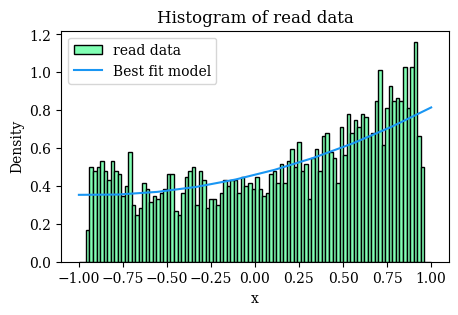

In [22]:
#define starting values for fit parameters a and b, and perform fit using Minuit

cost_fct = lambda a,b: neg_ln_likelihood(df["x"].values, a,b)
mfit = Minuit(cost_fct, a=0.5, b=0.5)
    
mfit.migrad()
a_fit, b_fit = mfit.values["a"], mfit.values["b"]

print(f"Best fit parameters: a={a_fit:.3f}, b={b_fit:.3f}")


x_plot = np.linspace(x_min, x_max, 10)

ax.plot(x_plot, fit_func_normalized(x_plot, a=a_fit, b=b_fit), color=my_cmap(0.2), label="Best fit model")
ax.legend()
fig

## 2b finding out the uncertainty by bootstrapping method

In [23]:
a_min, a_max, b_min, b_max

(0.3, 0.7, 0.1, 0.8)

In [24]:
def parametric_bootstrapping(xmin:float=-1, xmax:float=1, N_samples:int=10000, a:float=0.0, b:float=0.0, n_bootstrap:int=50):
    """generates pseudo data and fits parameters a and b for each pseudo dataset, returns arrays of fitted parameters
    Args:
        xmin (float): minimum x value for data generation
        xmax (float): maximum x value for data generation
        N_samples (int): number of samples to generate for each pseudo dataset
        a (float): parameter a for data generation
        b (float): parameter b for data generation
        n_bootstrap (int): number of bootstrap iterations to perform
    Returns:
        tuple: two lists containing the fitted parameters a and b for each pseudo dataset
    """
    pseudo_array=[]
    pseudo_array_a_fit=[]
    pseudo_array_b_fit=[]

    for i in range(n_bootstrap):
        data=sample_data_via_accept_reject(xmin=xmin, xmax=xmax, N_samples=N_samples, a=a, b=b)
        pseudo_array.append(data);

        mfit_pseudo = Minuit(lambda a,b: neg_ln_likelihood(data, a,b), a=0.0, b=0.0)
        #setting bounds for fit parameters a and b, and perform fit using Minuit
        mfit_pseudo.limits["a"] = (a_min, a_max)
        mfit_pseudo.limits["b"] = (b_min,b_max)
        mfit_pseudo.migrad()

        pseudo_array_a_fit.append(mfit_pseudo.values["a"])
        pseudo_array_b_fit.append(mfit_pseudo.values["b"])

    return pseudo_array_a_fit, pseudo_array_b_fit


pseudo_array_a_fit, pseudo_array_b_fit = parametric_bootstrapping(xmin=x_min, xmax=x_max, N_samples=3013, a=a_fit, b=b_fit, n_bootstrap=5) 


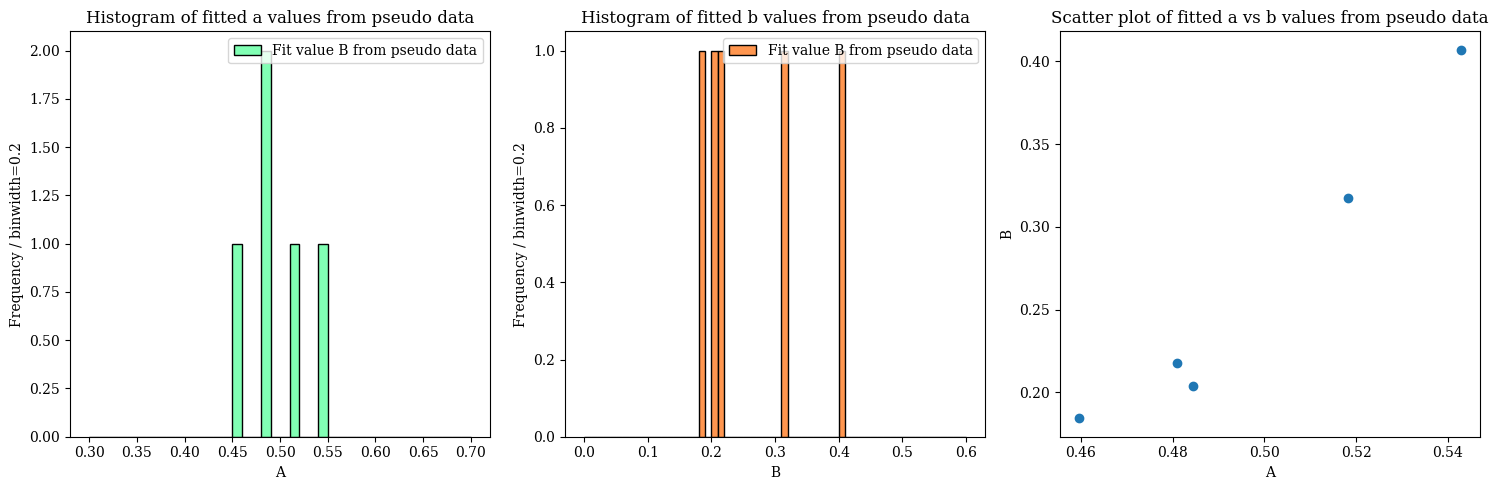

In [25]:
fig_bs,ax_bs=plt.subplots(1,3,figsize=(15, 5))
counts_a,bins_a,_=ax_bs[0].hist(pseudo_array_a_fit, bins=40,range=(0.3, 0.7), color=my_cmap(0.5), edgecolor='black',rwidth=1,label="Fit value B from pseudo data")
ax_bs[0].set_ylabel(f'Frequency / binwidth={2/10}')
ax_bs[0].set_xlabel('A')
ax_bs[0].set_title('Histogram of fitted a values from pseudo data')
ax_bs[0].legend()


counts_b,bins_b,_=ax_bs[1].hist(pseudo_array_b_fit, bins=60, range=(0, 0.6), color=my_cmap(0.8), edgecolor='black',rwidth=1,label="Fit value B from pseudo data")
ax_bs[1].set_ylabel(f'Frequency / binwidth={2/10}')
ax_bs[1].set_xlabel('B')
ax_bs[1].set_title('Histogram of fitted b values from pseudo data')
ax_bs[1].legend()


ax_bs[2].scatter(pseudo_array_a_fit,pseudo_array_b_fit)
ax_bs[2].set_xlabel('A')
ax_bs[2].set_ylabel('B')
ax_bs[2].set_title('Scatter plot of fitted a vs b values from pseudo data')

fig_bs.tight_layout()
#fig_bs.savefig('bootstrap_results.png')


## #2c

In [26]:
a_min, a_max, b_min, b_max= 0.3, 0.7,0.1,0.8

In [27]:
data_array=df["x"].values
min_llh = neg_ln_likelihood(data_array, a_fit, b_fit)

conf_factor = 2.3/2 #2 parameters, 68% confidence level

a_values = np.linspace(a_min, a_max, 50)
b_values = np.linspace(b_min, b_max, 50)
ab_contour=[]

for a_idx, a_val in enumerate(a_values):
    b_minus = b_min
    b_plus = b_min
    for b_idx, b_val in enumerate(b_values):
        if abs(neg_ln_likelihood(data_array, a_val, b_val) - min_llh) < conf_factor:
            if b_minus == b_min:
                b_minus = b_val
            b_plus = b_val
            #ab_contour[a_idx,b_idx] = 1
    if b_minus != b_min:
        ab_contour.append([a_val,b_minus])
        ab_contour.append([a_val,b_plus])

In [34]:
ab_contour;

In [ ]:
"""fig_contour, ax_contour = plt.subplots(1,figsize=(5, 5))
ab_a = np.array(ab_contour)
ax_contour.scatter(ab_a[:,0], ab_a[:,1], color=my_cmap(0.1), s=1)
ax_contour.scatter(a_fit, b_fit, color='black', marker=(5, 1), s=100, label='Calculated parameters')
ax_contour.set_ylabel('b')
ax_contour.set_xlabel('a')
ax_contour.set_title('Contour of 68% confidence region')
ax_contour.set_xlim(a_min, a_max)
ax_contour.set_ylim(b_min, b_max)

#better approach would be to go circular around the minimum in steps, search for the right distance, save point and go to the angular step. then interpolate
"""

"fig_contour, ax_contour = plt.subplots(1,figsize=(5, 5))\nab_a = np.array(ab_contour)\nax_contour.scatter(ab_a[:,0], ab_a[:,1], color=my_cmap(0.1), s=1)\nax_contour.scatter(a_fit, b_fit, color='black', marker=(5, 1), s=100, label='Calculated parameters')\nax_contour.set_ylabel('b')\nax_contour.set_xlabel('a')\nax_contour.set_title('Contour of 68% confidence region')\nax_contour.set_xlim(a_min, a_max)\nax_contour.set_ylim(b_min, b_max)\n"

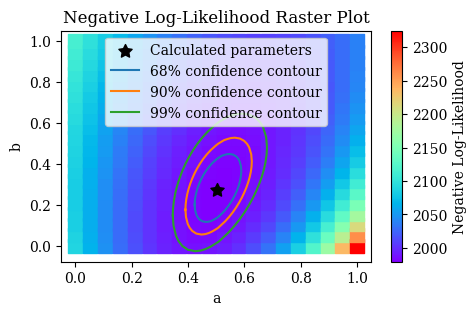

In [37]:
#https://scikit-hep.org/iminuit/notebooks/basic.html
#mfit.draw_mncontour("a", "b", cl=(0.68, 0.9, 0.99))

pts = mfit.mncontour("a", "b", cl=0.68, size=50)
x, y = np.transpose(pts)
ax_raster.plot(x, y, "-", label="68% confidence contour")

pts = mfit.mncontour("a", "b", cl=0.9, size=50)
x, y = np.transpose(pts)
ax_raster.plot(x, y, "-", label="90% confidence contour")

pts = mfit.mncontour("a", "b", cl=0.99, size=50)
x, y = np.transpose(pts)
ax_raster.plot(x, y, "-", label="99% confidence contour")

ax_raster.legend()
fig_raster

#ax_raster